In [1]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

print("Qiskit Version:", qiskit.__version__)
simulator = AerSimulator()
print(simulator)

def build_deutsch_oracle(function_type):
    """Build the oracle U_f for one of the four possible Boolean functions."""
    qc = QuantumCircuit(2, name=f"Oracle_{function_type}")

    if function_type == "constant_0":
        # f(x) = 0: do nothing
        pass

    elif function_type == "constant_1":
        # f(x) = 1: flip the target qubit
        qc.x(1)

    elif function_type == "balanced_x":
        # f(x) = x: target ^= x
        qc.cx(0, 1)

    elif function_type == "balanced_not_x":
        # f(x) = 1 - x: target ^= (1 - x)
        qc.x(1)
        qc.cx(0, 1)

    else:
        raise ValueError("Unknown function type.")

    return qc


def deutsch_algorithm(function_type, shots=1024):
    """Run Deutsch's algorithm and return the circuit and measurement counts."""
    oracle = build_deutsch_oracle(function_type)

    qc = QuantumCircuit(2, 1)

    # Prepare |0>|1>
    qc.x(1)

    # Create superposition
    qc.h(0)
    qc.h(1)

    # One oracle query
    qc.compose(oracle, inplace=True)

    # Interference on the control qubit
    qc.h(0)

    # Measure only the control qubit
    qc.measure(0, 0)

    counts = simulator.run(qc, shots=shots).result().get_counts()
    return qc, counts


def classify_deutsch_result(counts):
    """Interpret the control-qubit measurement."""
    result = max(counts, key=counts.get)
    return "constant" if result == "0" else "balanced"


Qiskit Version: 2.5.1
AerSimulator('aer_simulator')


In [2]:
def imperfect_hadamard(qc, qubit, epsilon):
    # Approximate H using RY(pi/2 + epsilon), introducing a small angle error.
    qc.ry(np.pi / 2 + epsilon, qubit)


def noisy_deutsch_algorithm(function_type, epsilon, shots=2000):
    oracle = build_deutsch_oracle(function_type)
    qc = QuantumCircuit(2, 1)

    # Prepare |0>|1>
    qc.x(1)

    # Imperfect first Hadamards
    imperfect_hadamard(qc, 0, epsilon)
    imperfect_hadamard(qc, 1, epsilon)

    # Oracle query
    qc.compose(oracle, inplace=True)

    # Imperfect final Hadamard on control
    imperfect_hadamard(qc, 0, epsilon)

    qc.measure(0, 0)

    counts = simulator.run(qc, shots=shots).result().get_counts()
    return counts


function_type = "balanced_x"
expected_result = "1"

errors = np.array([0.00, 0.05, 0.10, 0.20, 0.30, 0.40])
reliability = []

for epsilon in errors:
    counts = noisy_deutsch_algorithm(function_type, epsilon, shots=2000)
    correct = counts.get(expected_result, 0)
    reliability.append(correct / 2000)

print("Error (radians) | Correct-result reliability")
print("-" * 42)
for e, r in zip(errors, reliability):
    print(f"{e:14.2f} | {r:.3f}")


Error (radians) | Correct-result reliability
------------------------------------------
          0.00 | 0.000
          0.05 | 0.002
          0.10 | 0.001
          0.20 | 0.008
          0.30 | 0.025
          0.40 | 0.037


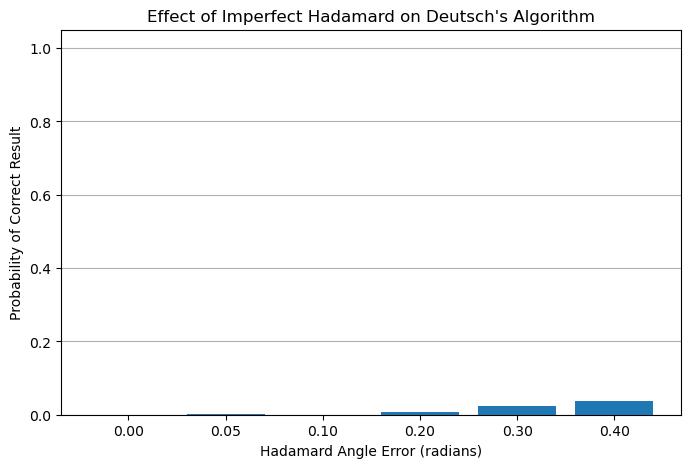

In [3]:
plt.figure(figsize=(8, 5))
plt.bar([f"{e:.2f}" for e in errors], reliability)
plt.xlabel("Hadamard Angle Error (radians)")
plt.ylabel("Probability of Correct Result")
plt.title("Effect of Imperfect Hadamard on Deutsch's Algorithm")
plt.ylim(0, 1.05)
plt.grid(axis="y")
plt.show()
